# Data-Driven Analysis of Potato Aroma: Genotype–VOC–Sensory Integration (Biorep1)

This notebook documents the executable analysis workflow underlying the
graduation thesis *“Data-Driven Analysis of Potato Flavour and Aroma Using
TD–GC–MS and Machine Learning”*.

The focus of this notebook is to:
  
- Evaluate genetic predictability of aroma compounds for independent generalisation check
_ This notebook should be run by  genemarker_module.py

In [1]:
import pandas as pd
import re
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.linear_model import LinearRegression
!pip install shap
from scipy.stats import t as tdist
from sklearn.model_selection import GridSearchCV
from scipy.stats import f
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import yaml
import importlib   
import genemarker_module
importlib.reload(genemarker_module)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<module 'genemarker_module' from 'c:\\Users\\fatemehm\\OneDrive - Royal HZPC Group\\documents\\GitHub\\internship\\functions\\genemarker_module.py'>

# Data Loading

In [2]:


with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Paths for Biorep1
genetic_path = config["biorep2"]["data"]["genetic_data"]
aroma_path   = config["biorep2"]["data"]["aroma_data"]
pc_df_path   = config["biorep2"]["data"]["sensory_data"]

# Load data
genetic_data = pd.read_csv(genetic_path)
aroma_df = pd.read_csv(aroma_path)
sensory_pcs = pd.read_excel(pc_df_path)


# Remove duplicate columns
sensory_pcs = sensory_pcs.loc[:, ~sensory_pcs.columns.duplicated()]


#  Remove useless 'Unnamed:' columns
sensory_pcs = sensory_pcs.loc[:, ~sensory_pcs.columns.str.contains("Unnamed")]


#  Normalize the Variety column name
if "VARIETY" in sensory_pcs.columns:
    sensory_pcs = sensory_pcs.rename(columns={"VARIETY": "Variety"})
elif "Variety_original" in sensory_pcs.columns:
    sensory_pcs = sensory_pcs.rename(columns={"Variety_original": "Variety"})

# Double-check the result
print("Final sensory PCA columns:", sensory_pcs.columns.tolist())
print("Variety exists:", "Variety" in sensory_pcs.columns)


Final sensory PCA columns: ['Variety', 'Variety_original', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, cluster 2 UK.1'

## Reshaping GC–MS data into wide aroma feature matrix


In [3]:
# Clean keys a bit 
aroma_df["Variety"] = aroma_df["Variety"].astype(str).str.strip()
aroma_df["Compound Name"] = aroma_df["Compound Name"].astype(str).str.strip()

# Pivot: columns become the 62 compounds, values are peak_Intensity
aroma_wide = (aroma_df
              .pivot_table(index="Variety",
                           columns="Compound Name",
                           values="peak_Intensity",
                           aggfunc="first")  
              .reset_index())

print("Aroma wide shape:", aroma_wide.shape)
print("Aroma compounds (should be 62):", aroma_wide.shape[1] - 1)


Aroma wide shape: (94, 62)
Aroma compounds (should be 62): 61


# Alignment and merging of genotype and phenotype tables


In [4]:

from genemarker_module import merge_genetic_aroma_sensory

# Clean Variety labels consistently
sensory_pcs["Variety"] = sensory_pcs["Variety"].astype(str).str.strip()
aroma_wide["Variety"]  = aroma_wide["Variety"].astype(str).str.strip()

# If sensory has duplicates per Variety, average numeric columns
sensory_pcs = (sensory_pcs
               .groupby("Variety", as_index=False)
               .mean(numeric_only=True))

print("Sensory after grouping:", sensory_pcs.shape,
      "| unique varieties:", sensory_pcs["Variety"].nunique())


# Run merge function 
merged_snp_aroma2, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data, aroma_wide, sensory_pcs
)
out_path = (
 
    "merged_snp_sensory_biorep2.csv"
)
merged_snp_aroma2.to_csv(out_path, index=False)

print(f"Saved biorep1 merged file to: {out_path}")

Sensory after grouping: (59, 15) | unique varieties: 59
 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 61
  Dropped (all NaN): 0
  Final usable aroma columns: 61
  Sample aroma cols: ['(E)-2-Heptenal', '1-Heptanol', '1-Hexanol, 2-ethyl-', '1-Nonanol', '1-Phenylethanol', '2(3H)-Furanone, dihydro-5-pentyl-', '2,3-Butanedione', '2,3-Pentanedione']

# Sensory PCs: 14
Sample sensory cols: ['cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, cluster 2 UK.1', 'number ID', 'citric acid']

# Merge results:
  Genetic + Aroma: (94, 262495)
  Genetic + Sensory: (20, 262448)
  Genetic + Aroma + Sensory: (94, 262509)
Saved biorep1 merged file to: merged_snp_sensory_biorep2.csv


# independent generalisation check

In [12]:

from genemarker_module import run_linear_models_independent_generalisation


#  Paths (TRAIN = biorep1)

gwas_file_train = config["biorep1"]["data"]["gwas_output_gene_aroma"]

df_linear_cv_path = config["biorep1"]["data"]["df_linear_cv_biorep1_output"]
df_linear_cv_biorep1 = pd.read_csv(df_linear_cv_path)


snp_biorep1 = pd.read_csv(
    config["biorep1"]["data"]["merged_snp_aroma_output"]
)





#  Column cleanup (Variety)
for df in (snp_biorep1, merged_snp_aroma2):
    df.columns = df.columns.astype(str).str.strip()
    if "VARIETY" in df.columns and "Variety" not in df.columns:
        df.rename(columns={"VARIETY": "Variety"}, inplace=True)


#  Run independent test
df_linear_independent = run_linear_models_independent_generalisation(
    df_linear_cv=df_linear_cv_biorep1,
    gwas_file=gwas_file_train,     # IMPORTANT: train GWAS (biorep1)
    snp_train=snp_biorep1,         # biorep1 merged SNP+trait matrix
    snp_indep=merged_snp_aroma2,         # biorep2 merged SNP+trait matrix
    n_snps=300,
    prune_threshold=0.95
)

df_linear_independent.head(10)


,Trait,Model,R2,RMSE,MAE
0,1-Heptanol,Ridge,-14.790940,4.688823e+05,2.433244e+05
1,1-Nonanol,Ridge,-75.774941,2.748814e+05,1.281770e+05
2,1-Phenylethanol,ElasticNet,-20.468670,7.039351e+04,3.705567e+04
3,"2(3H)-Furanone, dihydro-5-pentyl-",Ridge,-2.881852,1.241824e+06,6.967703e+05
4,"2,3-Butanedione",Ridge,-1.093775,1.074929e+06,8.652677e+05
5,2-Ethylfuran,Ridge,-0.362184,4.025540e+05,1.996276e+05
6,2-Heptanone,Ridge,-4475.334047,1.787842e+06,1.508152e+06
7,2-Methylbutanal,Ridge,-11.067492,2.345741e+05,1.689388e+05
8,2-Methylpropanal,Ridge,-4.435645,8.737114e+05,6.467083e+05
9,2-Nonanone,ElasticNet,-10.387767,3.491005e+05,2.043603e+05


In [6]:
out_path = (

    "best_linear_independent_top_models.csv"
)


df_linear_independent.to_csv(out_path, index=False)

print(f"Saved to: {out_path}")
independent= pd.read_csv("best_linear_independent_top_models.csv")
print(independent)

Saved to: best_linear_independent_top_models.csv
                                Trait       Model           R2          RMSE  \
0                          1-Heptanol       Ridge   -14.790940  4.688823e+05   
1                           1-Nonanol       Ridge   -75.774941  2.748814e+05   
2                     1-Phenylethanol  ElasticNet   -20.468670  7.039351e+04   
3   2(3H)-Furanone, dihydro-5-pentyl-       Ridge    -2.881852  1.241824e+06   
4                     2,3-Butanedione       Ridge    -1.093775  1.074929e+06   
5                        2-Ethylfuran       Ridge    -0.362184  4.025540e+05   
6                         2-Heptanone       Ridge -4475.334047  1.787842e+06   
7                     2-Methylbutanal       Ridge   -11.067492  2.345741e+05   
8                    2-Methylpropanal       Ridge    -4.435645  8.737114e+05   
9                          2-Nonanone  ElasticNet   -10.387767  3.491005e+05   
10            2-Propanone, 1-methoxy-       Ridge   -10.408776  8.23501

<Figure size 700x500 with 0 Axes>

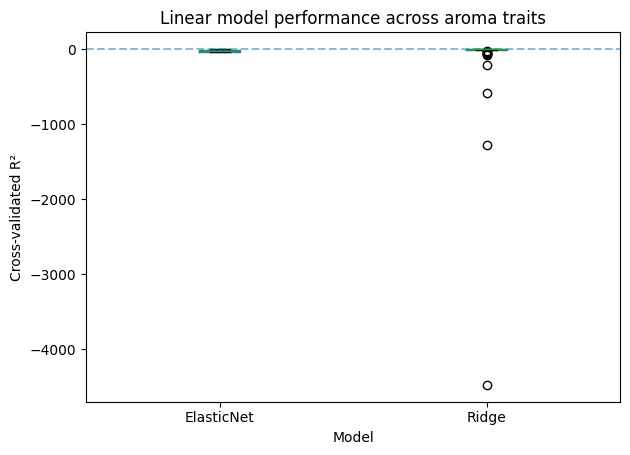

In [9]:
plt.figure(figsize=(7, 5))
df_linear_independent.boxplot(column="R2", by="Model", grid=False)
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Linear model performance across aroma traits")
plt.suptitle("")
plt.ylabel("Cross-validated R²")
plt.tight_layout()
plt.show()

In [ ]:
# 1) ستون‌های مشترک (SNP + Traits) را دقیق چک کن
snps1 = [c for c in snp_biorep1.columns if c.startswith("GEN__")]
snps2 = [c for c in merged_snp_aroma2.columns if c.startswith("GEN__")]
print("SNP overlap:", len(set(snps1)&set(snps2)), " / ", len(set(snps1)|set(snps2)))

traits1 = [c for c in snp_biorep1.columns if (c not in snps1) and c not in ["Variety"]]
traits2 = [c for c in merged_snp_aroma2.columns if (c not in snps2) and c not in ["Variety"]]
print("Trait overlap:", len(set(traits1)&set(traits2)))
print("Missing in biorep2:", sorted(set(traits1)-set(traits2))[:20])


check_traits = ["1-Heptanol","1-Nonanol","alpha-Terpineol"]
for t in check_traits:
    if t in snp_biorep1.columns and t in merged_snp_aroma2.columns:
        a = snp_biorep1[t].astype(float)
        b = merged_snp_aroma2[t].astype(float)
        print(t, "mean/std rep1:", a.mean(), a.std(), " | rep2:", b.mean(), b.std())


for df in (snp_biorep1, merged_snp_aroma2):
    df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed:")], inplace=True, errors="ignore")


SNP overlap: 262434  /  262434
